# Ti64 Statistical Modelling
## Plotting Beta approach curves from literature
### Rory Atlasi Barker, Guy Bowker

This notebook can be used to filter beta-approach curves for Ti64 volume fraction measurments from literature.
Change the temperature range, microstructure, strain rate, or other options in the example cells at the bottom to plot the corresponding curves for those conditions.
Functions can be found next to this notebook in `utils.py`.
To add data from a paper, simply create a new file in this repository named after the paper authors as shown containing the data as a `.csv` file.
Then add the papers metadata and relative filepath to the `beta-approach_curves.yaml` file.

In [1]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import yaml
from yaml.loader import FullLoader
from yaml.loader import SafeLoader
from utils import sort_curve
from utils import curve_filter
from utils import curve_filter_pd
from utils import beta_approach_curve_plotter

%matplotlib inline

Load `beta-approach_curves.yml` file and
check number of papers:

In [2]:
lit_data = yaml.load(open('beta-approach_curves.yml'), Loader=SafeLoader)
lit_data['Papers'].keys()

dict_keys(['Janda_2022', 'Semiatin_2002', 'Tamiri_2005'])

In [9]:
# Save beta-approach data to lit_data dictionary with metadata
# Save lit_data dictionary as varibale to be used elsewhere.
for paper in lit_data['Papers'].keys():
    print(f"Getting data for {paper}...")
    for curve_no, curve_metadata in enumerate(lit_data['Papers'][paper]['Curves']):
        print(f"\t{lit_data['Papers'][paper]['Curves'][curve_no]['Curve_location'][-25:]}...")
        approach_data = pd.read_csv(lit_data['Papers'][paper]['Curves'][curve_no]['Curve_location'],
                                     sep=",", skiprows=0)
        lit_data['Papers'][paper]['Curves'][curve_no]['data'] = approach_data
pickle.dump(lit_data, open('lit_beta-approach_curves.pkl', 'wb'))

Getting data for Janda_2022...
	da_2022_fig9_measured.csv...
Getting data for Semiatin_2002...
	_fig6_castro&seraphin.csv...
	tin_2002_fig6_microbe.csv...
	002_fig6_quant_metall.csv...
Getting data for Tamiri_2005...
	/Tamiri_2005_measured.csv...


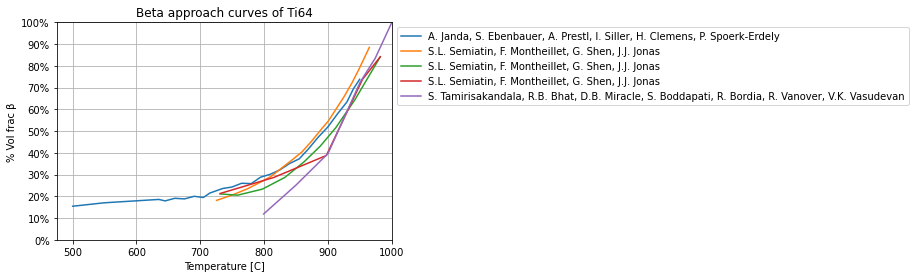

In [10]:
fig_no = 1
curve_list_filtered, no_curves, Paper_list, Authors = curve_filter(lit_data)
beta_approach_curve_plotter(curve_list_filtered, fig_no, Authors)


WORK IN PROGRESS

In [5]:
plt.figure(figsize=(6,6), dpi=300, facecolor="white")

# Semiatin 2002_quant_metall
sem_2002 = lit_data['Papers'][paper]['Curves'][curve_no]['data']
plt.plot(sem_2002_quantmetall.iloc[:,0], sem_2002_quantmetall.iloc[:,1],
         linestyle="None", marker="o", color='k', label="sem_2002_quant_metall")

# Semiatin 2002_microbe
plt.plot(sem_2002_microbe.iloc[:,0], sem_2002_microbe.iloc[:,1],
         color='k', label="sem_2002_microbe")

# Castro & Serphin 1966
plt.plot(castro_1966_measured.iloc[:,0], castro_1966_measured.iloc[:,1],
         linestyle="dashed", color='k', label="Castro_1966")

# Tamirisakandala 2005
plt.scatter(tamiri_2005_measured.iloc[:,0], tamiri_2005_measured.iloc[:,1],
         linestyle="None", marker='o', facecolors='none', edgecolors='k', label="Tamiri_2005")

# Janda 2022
plt.scatter(janda_2022_measured.iloc[:,0], janda_2022_measured.iloc[:,1],
         linestyle="None", marker='o', facecolors='none', edgecolors='r', label="Janda_2022")

plt.xlim([None,1000])
plt.xlabel(f"Temperature [C]")
plt.ylim([0,100])
plt.ylabel(f"% Vol frac β")
plt.yticks([0,10,20,30,40,50,60,70,80,90,100],
           ["0%","10%","20%","30%","40%","50%","60%","70%","80%","90%","100%"])
plt.grid()
plt.legend()

NameError: name 'sem_2002_quantmetall' is not defined

<Figure size 1800x1800 with 0 Axes>